# Análisis de Dispersión y Comparaciones

Este notebook explora las relaciones entre variables mediante gráficos de dispersión y comparaciones para identificar patrones, tendencias y posibles asociaciones entre divorcios y diferentes tipos de VIF.

In [4]:
# Importar librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import sys
from scipy import stats

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
%matplotlib inline

In [5]:
# Cargar el módulo data_pipeline desde el directorio padre
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import data_pipeline as dp

# Cargar datos del panel
panel = dp.build_panel(force_rebuild=False).dropna(subset=['departamento', 'anio']).copy()
print(f"Dimensiones del panel: {panel.shape}")
print(f"\nPrimeras filas del dataset:")
panel.head()

Dimensiones del panel: (351, 120)

Primeras filas del dataset:


,departamento,anio,divorcios_total,vif_total,vif_sexo_hombres,vif_sexo_mujeres,vif_tipo_fisica,vif_tipo_fisica_patrimonial,vif_tipo_fisica_psicologica,vif_tipo_fisica_psicologica_patrimonial,...,vif_edad_90,vif_edad_91,vif_edad_92,vif_edad_93,vif_edad_94,vif_edad_95,vif_edad_96,vif_edad_97,vif_edad_98,vif_edad_99
0,Baja Verapaz,2000,NaN,1,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,Guatemala,2000,NaN,3,0,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Chimaltenango,2001,NaN,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Guatemala,2001,NaN,8,1,7,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,Izabal,2001,NaN,1,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


## 1. Dispersión: Divorcios vs VIF Total

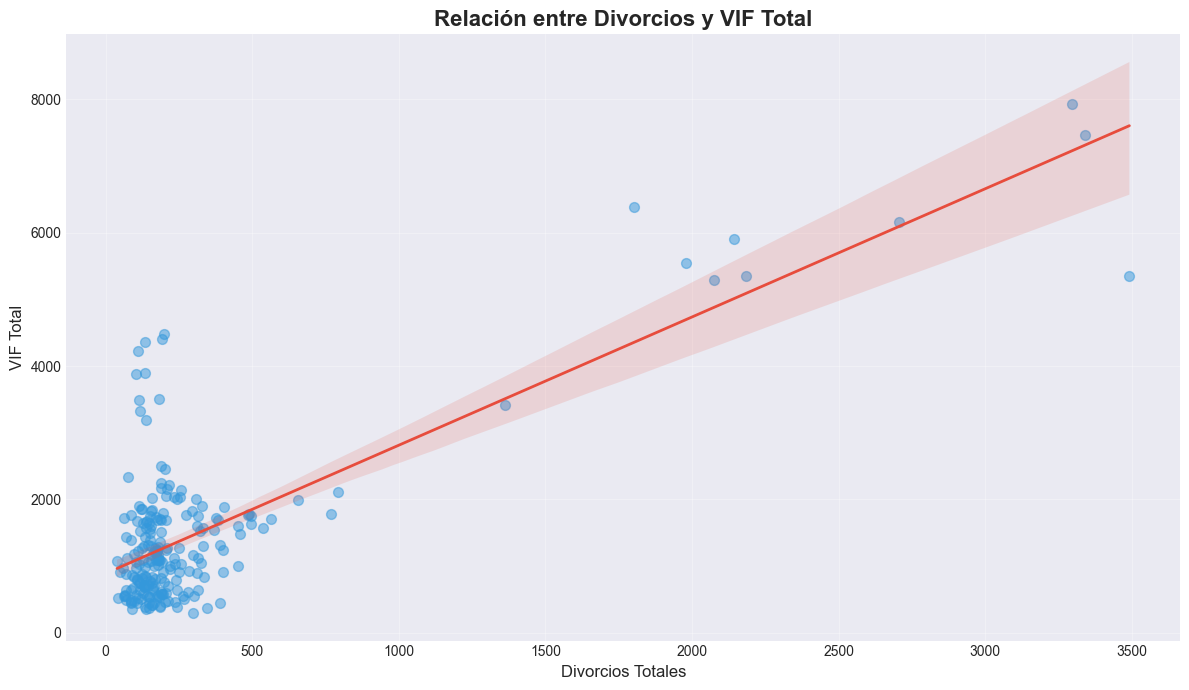


Coeficiente de correlación de Pearson: nan
P-valor: nan
La correlación no es estadísticamente significativa (p >= 0.05)


In [6]:
# Gráfico de dispersión con línea de regresión
plt.figure(figsize=(12, 7))
sns.regplot(data=panel, x='divorcios_total', y='vif_total', 
            scatter_kws={'alpha': 0.5, 's': 50, 'color': '#3498db'},
            line_kws={'color': '#e74c3c', 'linewidth': 2})
plt.title('Relación entre Divorcios y VIF Total', fontsize=16, fontweight='bold')
plt.xlabel('Divorcios Totales', fontsize=12)
plt.ylabel('VIF Total', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calcular correlación
correlacion, p_valor = stats.pearsonr(panel['divorcios_total'], panel['vif_total'])
print(f"\nCoeficiente de correlación de Pearson: {correlacion:.3f}")
print(f"P-valor: {p_valor:.4e}")
if p_valor < 0.05:
    print("La correlación es estadísticamente significativa (p < 0.05)")
else:
    print("La correlación no es estadísticamente significativa (p >= 0.05)")

**Conclusión:** Este gráfico explora si existe una relación lineal entre el número de divorcios y los casos de VIF. Una correlación positiva podría sugerir que en contextos con más divorcios también hay más violencia intrafamiliar reportada, aunque esto no implica causalidad. La dispersión de los puntos indica la variabilidad de esta relación. Factores como el tamaño poblacional o la urbanización podrían estar influyendo en ambas variables simultáneamente.

## 2. Dispersión por Año con Colores

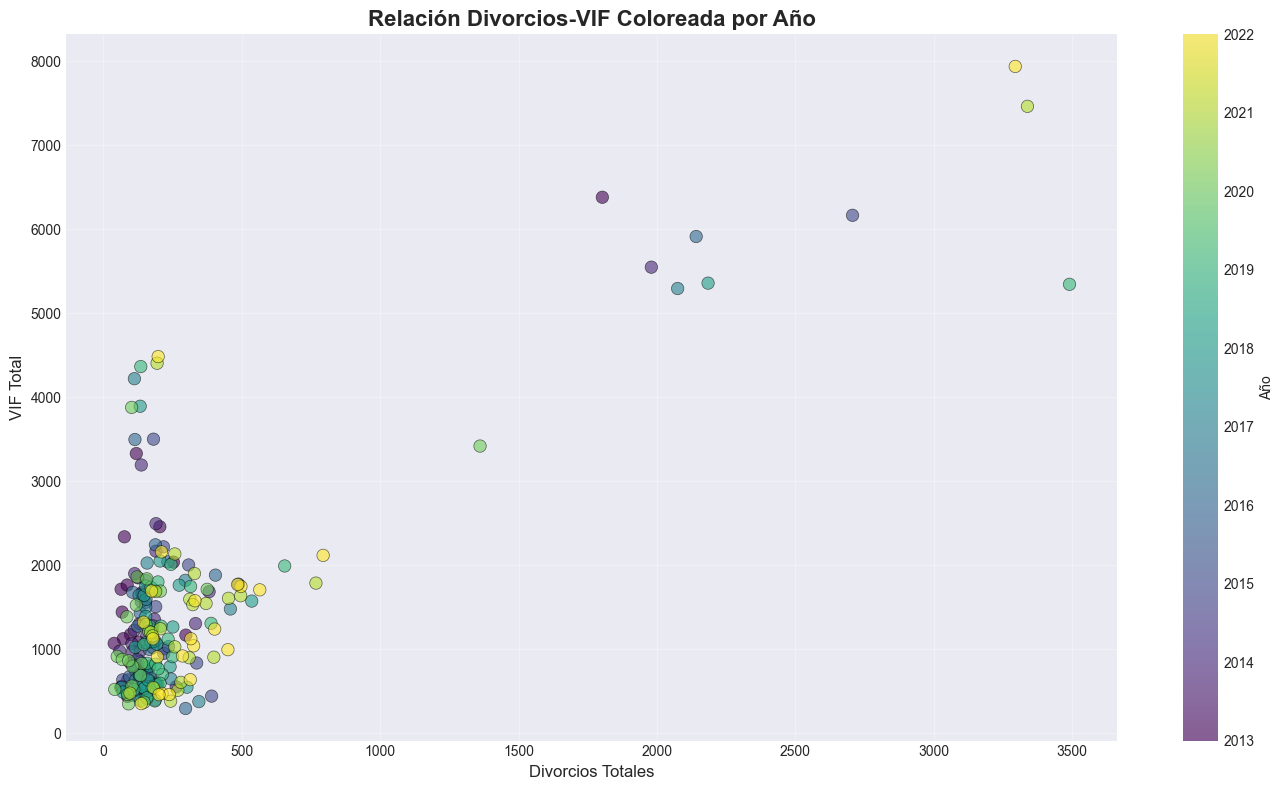

In [7]:
# Gráfico de dispersión coloreado por año
plt.figure(figsize=(14, 8))
scatter = plt.scatter(panel['divorcios_total'], panel['vif_total'], 
                      c=panel['anio'], cmap='viridis', 
                      s=80, alpha=0.6, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='Año')
plt.title('Relación Divorcios-VIF Coloreada por Año', fontsize=16, fontweight='bold')
plt.xlabel('Divorcios Totales', fontsize=12)
plt.ylabel('VIF Total', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Conclusión:** Al colorear los puntos por año, podemos detectar si la relación entre divorcios y VIF ha cambiado en el tiempo. Si los puntos de años recientes se agrupan en ciertas regiones del gráfico, esto podría indicar tendencias temporales en cómo estas variables se relacionan. Por ejemplo, podría haber un aumento conjunto en años específicos, lo que sugeriría factores temporales comunes que afectan ambas variables.

## 3. Comparación de Tipos de VIF

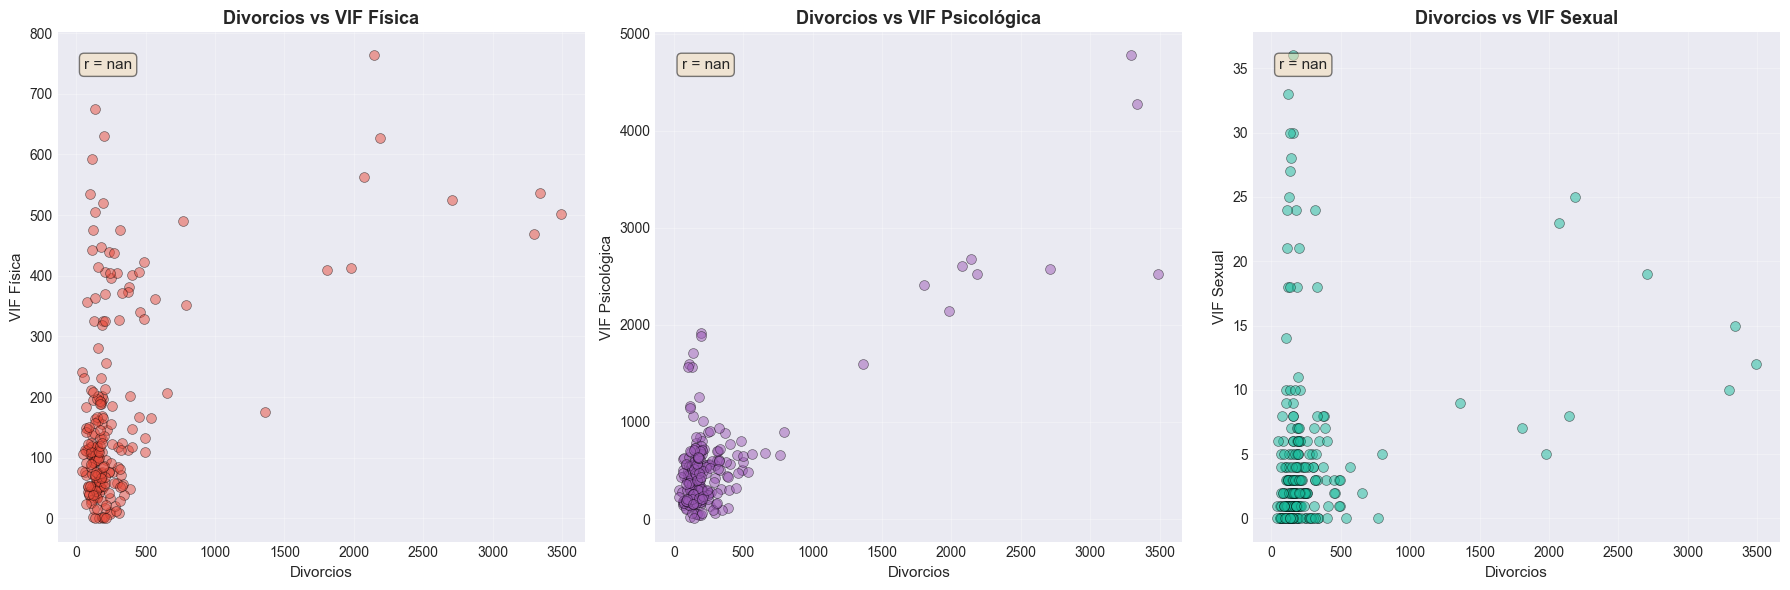

In [8]:
# Crear subplots para comparar divorcios con cada tipo de VIF
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# VIF Física
axes[0].scatter(panel['divorcios_total'], panel['vif_tipo_fisica'], 
                alpha=0.5, s=50, color='#e74c3c', edgecolors='black', linewidth=0.5)
axes[0].set_title('Divorcios vs VIF Física', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Divorcios', fontsize=11)
axes[0].set_ylabel('VIF Física', fontsize=11)
axes[0].grid(True, alpha=0.3)
corr_fisica, _ = stats.pearsonr(panel['divorcios_total'], panel['vif_tipo_fisica'])
axes[0].text(0.05, 0.95, f'r = {corr_fisica:.3f}', transform=axes[0].transAxes, 
             fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# VIF Psicológica
axes[1].scatter(panel['divorcios_total'], panel['vif_tipo_psicologica'], 
                alpha=0.5, s=50, color='#9b59b6', edgecolors='black', linewidth=0.5)
axes[1].set_title('Divorcios vs VIF Psicológica', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Divorcios', fontsize=11)
axes[1].set_ylabel('VIF Psicológica', fontsize=11)
axes[1].grid(True, alpha=0.3)
corr_psico, _ = stats.pearsonr(panel['divorcios_total'], panel['vif_tipo_psicologica'])
axes[1].text(0.05, 0.95, f'r = {corr_psico:.3f}', transform=axes[1].transAxes, 
             fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# VIF Sexual
axes[2].scatter(panel['divorcios_total'], panel['vif_tipo_sexual'], 
                alpha=0.5, s=50, color='#1abc9c', edgecolors='black', linewidth=0.5)
axes[2].set_title('Divorcios vs VIF Sexual', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Divorcios', fontsize=11)
axes[2].set_ylabel('VIF Sexual', fontsize=11)
axes[2].grid(True, alpha=0.3)
corr_sexual, _ = stats.pearsonr(panel['divorcios_total'], panel['vif_tipo_sexual'])
axes[2].text(0.05, 0.95, f'r = {corr_sexual:.3f}', transform=axes[2].transAxes, 
             fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

**Conclusión:** La comparación lado a lado permite evaluar si los divorcios se relacionan de manera diferente con cada tipo de violencia. Es posible que algunos tipos de VIF muestren correlaciones más fuertes con los divorcios que otros. Por ejemplo, la violencia psicológica o física podría estar más asociada con la disolución matrimonial que la violencia sexual. Estas diferencias pueden proporcionar insights sobre las dinámicas familiares que conducen al divorcio.

## 4. Dispersión: VIF Hombres vs Mujeres

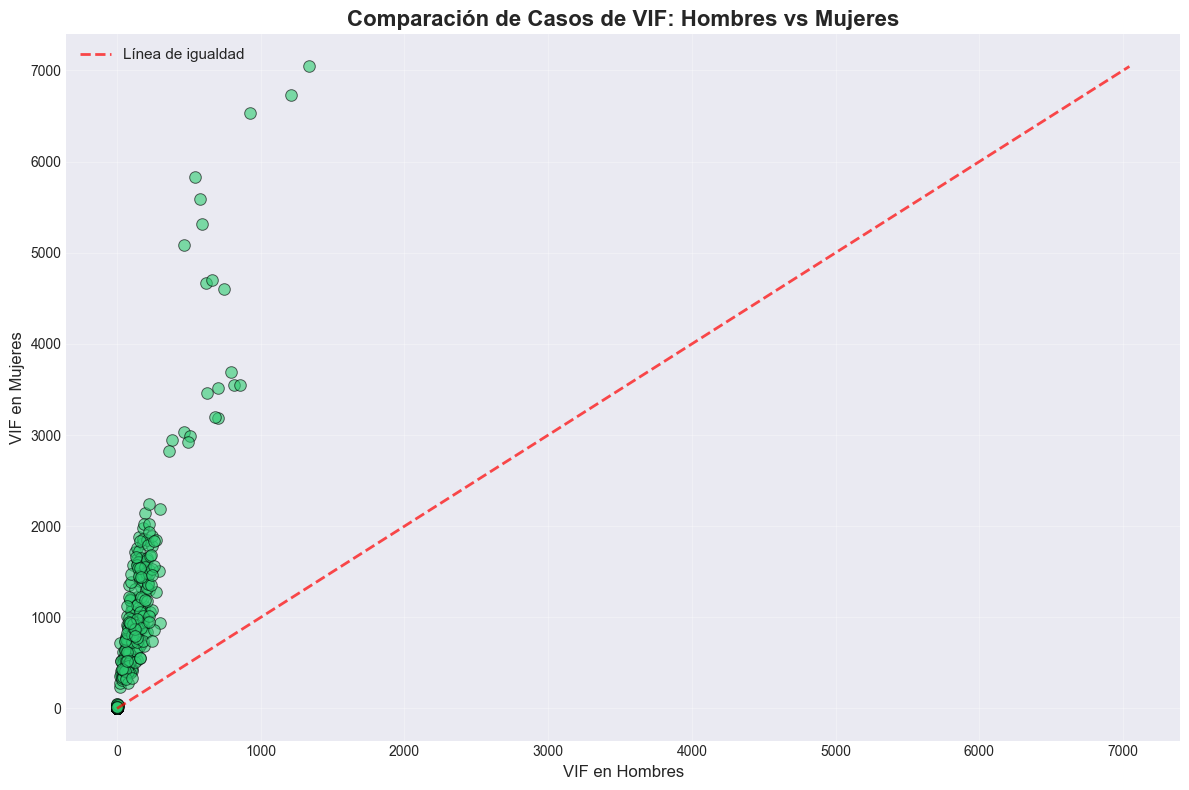


Media VIF Hombres: 124.79
Media VIF Mujeres: 900.25
Ratio Mujeres/Hombres: 7.21


In [9]:
# Comparar casos de VIF entre hombres y mujeres
plt.figure(figsize=(12, 8))
plt.scatter(panel['vif_sexo_hombres'], panel['vif_sexo_mujeres'], 
            alpha=0.6, s=70, c='#2ecc71', edgecolors='black', linewidth=0.7)

# Agregar línea de igualdad
max_val = max(panel['vif_sexo_hombres'].max(), panel['vif_sexo_mujeres'].max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Línea de igualdad', alpha=0.7)

plt.title('Comparación de Casos de VIF: Hombres vs Mujeres', fontsize=16, fontweight='bold')
plt.xlabel('VIF en Hombres', fontsize=12)
plt.ylabel('VIF en Mujeres', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Estadísticas comparativas
print(f"\nMedia VIF Hombres: {panel['vif_sexo_hombres'].mean():.2f}")
print(f"Media VIF Mujeres: {panel['vif_sexo_mujeres'].mean():.2f}")
print(f"Ratio Mujeres/Hombres: {panel['vif_sexo_mujeres'].mean() / panel['vif_sexo_hombres'].mean():.2f}")

**Conclusión:** Este gráfico muestra claramente la disparidad de género en la violencia intrafamiliar. La mayoría de los puntos están por encima de la línea de igualdad, indicando que en casi todos los casos hay más víctimas mujeres que hombres. La distancia de cada punto a la línea roja representa la magnitud de esta diferencia en cada observación. Este patrón es consistente con la literatura sobre violencia de género y refuerza la necesidad de políticas específicas de protección a mujeres.

## 5. Pairplot de Variables Principales

c:\Users\felip\Documents\Studies\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
c:\Users\felip\Documents\Studies\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
c:\Users\felip\Documents\Studies\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(x=vector, **plot_kwargs)
c:\Users\felip\Documents\Studies\.venv\Lib\site-packages\seaborn\axisgrid.py:1513: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an 

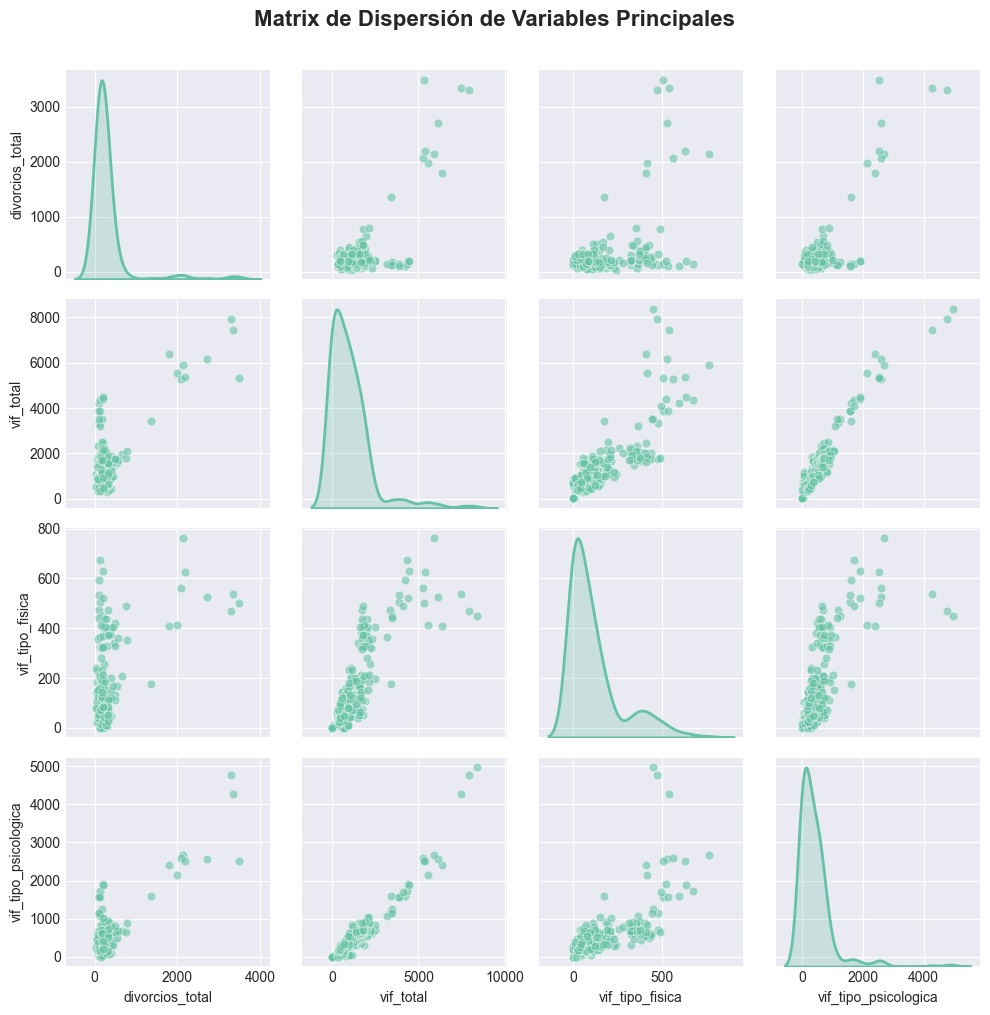

In [10]:
# Seleccionar subset de variables para pairplot
variables_subset = ['divorcios_total', 'vif_total', 'vif_tipo_fisica', 'vif_tipo_psicologica']
datos_subset = panel[variables_subset]

# Crear pairplot
g = sns.pairplot(datos_subset, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 40},
                 diag_kws={'shade': True, 'linewidth': 2})
g.fig.suptitle('Matrix de Dispersión de Variables Principales', 
               fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Conclusión:** El pairplot proporciona una visión integral de todas las relaciones bivariadas entre las variables seleccionadas. Los gráficos de la diagonal muestran la distribución de cada variable, mientras que los gráficos fuera de la diagonal muestran las relaciones entre pares de variables. Esta visualización matricial es útil para detectar patrones generales, identificar relaciones no lineales y descubrir qué pares de variables merecen análisis más detallado. Las formas de las nubes de puntos pueden sugerir diferentes tipos de relaciones.

## 6. Comparación Temporal: Evolución Departamento Guatemala

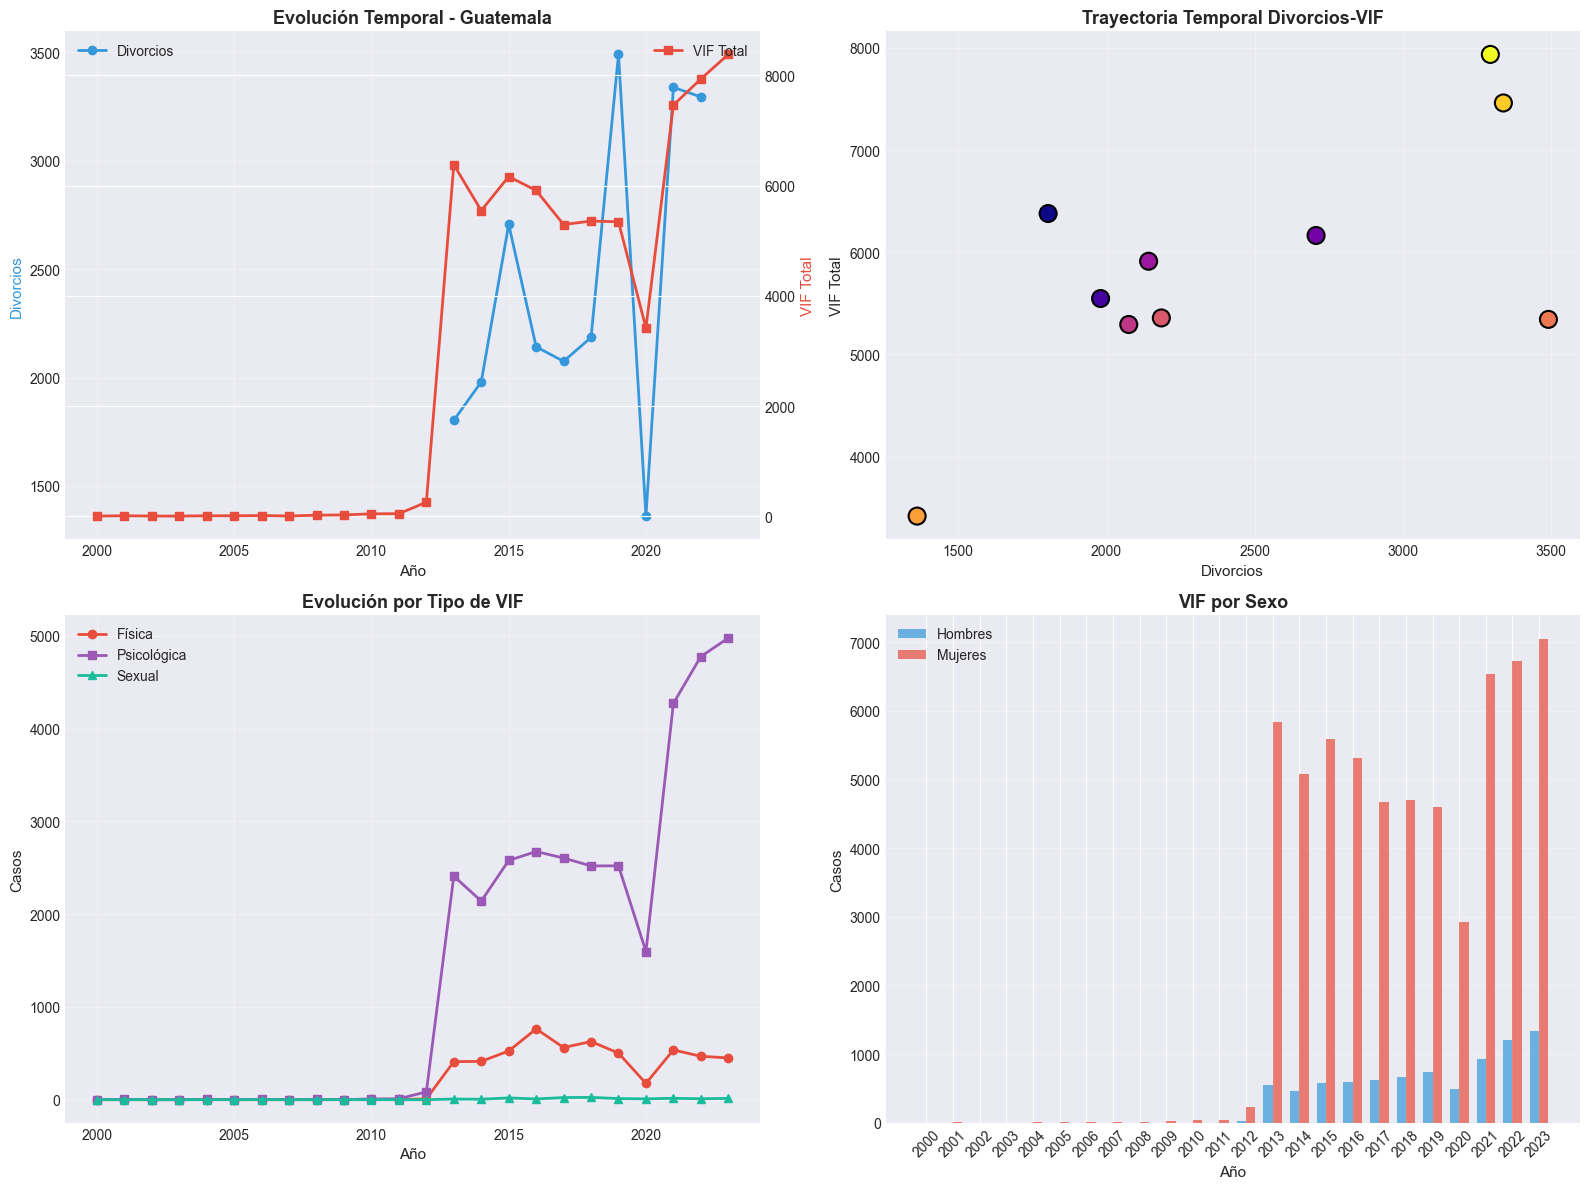

In [11]:
# Filtrar datos de un departamento específico para análisis temporal
# Intentar con Guatemala, si no existe, usar el primer departamento
departamentos_unicos = panel['departamento'].unique()
dept_analisis = 'Guatemala' if 'Guatemala' in departamentos_unicos else departamentos_unicos[0]

panel_dept = panel[panel['departamento'] == dept_analisis].sort_values('anio')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Divorcios vs VIF en el tiempo
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()
ax1.plot(panel_dept['anio'], panel_dept['divorcios_total'], 
         marker='o', linewidth=2, color='#3498db', label='Divorcios')
ax1_twin.plot(panel_dept['anio'], panel_dept['vif_total'], 
              marker='s', linewidth=2, color='#e74c3c', label='VIF Total')
ax1.set_xlabel('Año', fontsize=11)
ax1.set_ylabel('Divorcios', fontsize=11, color='#3498db')
ax1_twin.set_ylabel('VIF Total', fontsize=11, color='#e74c3c')
ax1.set_title(f'Evolución Temporal - {dept_analisis}', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')

# Gráfico 2: Scatter divorcios vs VIF en el tiempo
axes[0, 1].scatter(panel_dept['divorcios_total'], panel_dept['vif_total'], 
                   c=panel_dept['anio'], cmap='plasma', s=150, 
                   edgecolors='black', linewidth=1.5)
axes[0, 1].set_xlabel('Divorcios', fontsize=11)
axes[0, 1].set_ylabel('VIF Total', fontsize=11)
axes[0, 1].set_title('Trayectoria Temporal Divorcios-VIF', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Gráfico 3: Tipos de VIF
axes[1, 0].plot(panel_dept['anio'], panel_dept['vif_tipo_fisica'], 
                marker='o', linewidth=2, label='Física', color='#e74c3c')
axes[1, 0].plot(panel_dept['anio'], panel_dept['vif_tipo_psicologica'], 
                marker='s', linewidth=2, label='Psicológica', color='#9b59b6')
axes[1, 0].plot(panel_dept['anio'], panel_dept['vif_tipo_sexual'], 
                marker='^', linewidth=2, label='Sexual', color='#1abc9c')
axes[1, 0].set_xlabel('Año', fontsize=11)
axes[1, 0].set_ylabel('Casos', fontsize=11)
axes[1, 0].set_title('Evolución por Tipo de VIF', fontsize=13, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 4: VIF por sexo
width = 0.35
x_pos = np.arange(len(panel_dept))
axes[1, 1].bar(x_pos - width/2, panel_dept['vif_sexo_hombres'], 
               width, label='Hombres', color='#3498db', alpha=0.7)
axes[1, 1].bar(x_pos + width/2, panel_dept['vif_sexo_mujeres'], 
               width, label='Mujeres', color='#e74c3c', alpha=0.7)
axes[1, 1].set_xlabel('Año', fontsize=11)
axes[1, 1].set_ylabel('Casos', fontsize=11)
axes[1, 1].set_title('VIF por Sexo', fontsize=13, fontweight='bold')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(panel_dept['anio'].values, rotation=45)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Conclusión:** Este análisis multi-panel enfocado en un departamento específico permite observar cómo evolucionan conjuntamente los divorcios y la VIF en el tiempo. La trayectoria en el scatter plot muestra si ambas variables se mueven de forma sincronizada o independiente. Analizar departamentos individuales ayuda a identificar patrones locales que podrían perderse en análisis agregados. Cada departamento puede tener dinámicas únicas influenciadas por factores demográficos, culturales y económicos específicos, por lo que este tipo de análisis desagregado es fundamental para políticas públicas focalizadas.

# Dispersión y Comparaciones: Relaciones entre Variables
Este cuaderno explora las relaciones bivariadas entre divorcios, violencia intrafamiliar y sus desagregaciones
mediante gráficos de dispersión, análisis de correlación y comparaciones grupales.

In [12]:
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name != 'MD_Proyecto1':
    for parent in PROJECT_ROOT.parents:
        if parent.name == 'MD_Proyecto1':
            PROJECT_ROOT = parent
            break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import data_pipeline as dp
dp = importlib.reload(dp)

# Cargar el panel de datos
panel = dp.build_panel(force_rebuild=False, only_common_years=False).dropna(subset=['departamento', 'anio']).copy()
panel[['divorcios_total', 'vif_total']] = panel[['divorcios_total', 'vif_total']].fillna(0)
print(f"Panel cargado: {len(panel)} registros")
print(f"Años: {int(panel['anio'].min())}-{int(panel['anio'].max())}")

# Configuración visual
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

Panel cargado: 351 registros
Años: 2000-2023


## 1. Dispersión: Divorcios vs Violencia Intrafamiliar
Exploramos la relación fundamental entre divorcios y VIF.

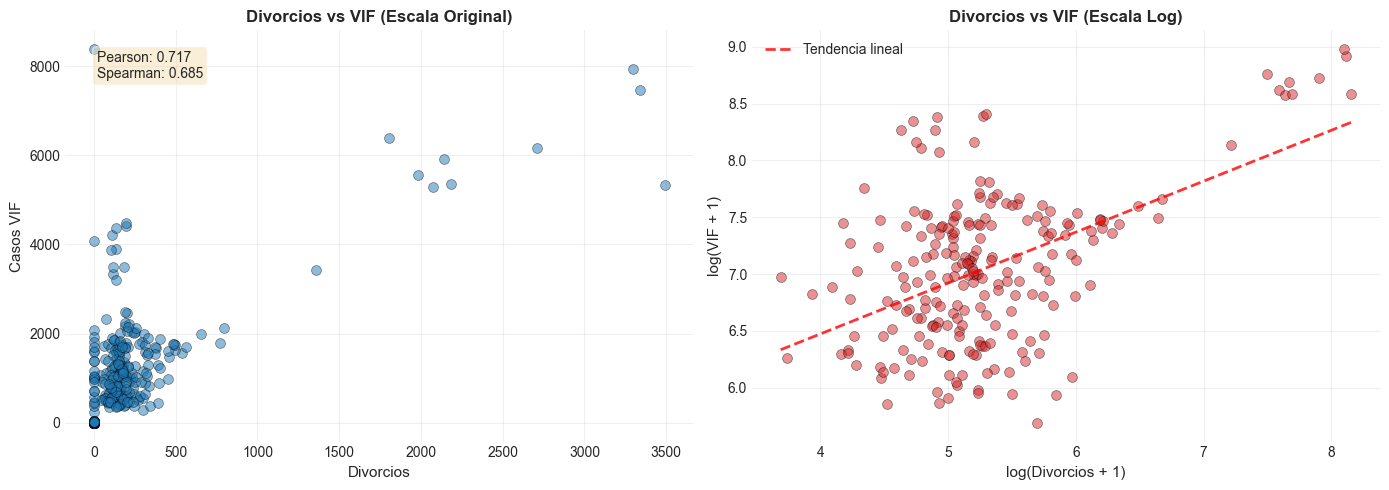


Correlación Pearson: 0.717
Correlación Spearman: 0.685

La correlación de Spearman es más robusta a outliers y distribuciones asimétricas.


In [13]:
# Filtrar datos con ambas variables presentes
panel_completo = panel[(panel['divorcios_total'] > 0) | (panel['vif_total'] > 0)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dispersión escala original
axes[0].scatter(panel_completo['divorcios_total'], panel_completo['vif_total'], 
                alpha=0.5, s=50, c='#1f78b4', edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('Divorcios', fontsize=11)
axes[0].set_ylabel('Casos VIF', fontsize=11)
axes[0].set_title('Divorcios vs VIF (Escala Original)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Calcular correlación
corr_pearson = panel_completo[['divorcios_total', 'vif_total']].corr().iloc[0, 1]
corr_spearman = panel_completo[['divorcios_total', 'vif_total']].corr(method='spearman').iloc[0, 1]
axes[0].text(0.05, 0.95, f'Pearson: {corr_pearson:.3f}\nSpearman: {corr_spearman:.3f}',
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Dispersión escala log
panel_positivos = panel_completo[(panel_completo['divorcios_total'] > 0) & (panel_completo['vif_total'] > 0)]
axes[1].scatter(np.log1p(panel_positivos['divorcios_total']), np.log1p(panel_positivos['vif_total']),
                alpha=0.5, s=50, c='#d62728', edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('log(Divorcios + 1)', fontsize=11)
axes[1].set_ylabel('log(VIF + 1)', fontsize=11)
axes[1].set_title('Divorcios vs VIF (Escala Log)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Línea de tendencia
if len(panel_positivos) > 1:
    z = np.polyfit(np.log1p(panel_positivos['divorcios_total']), 
                   np.log1p(panel_positivos['vif_total']), 1)
    p = np.poly1d(z)
    x_line = np.linspace(np.log1p(panel_positivos['divorcios_total']).min(), 
                         np.log1p(panel_positivos['divorcios_total']).max(), 100)
    axes[1].plot(x_line, p(x_line), 'r--', linewidth=2, alpha=0.8, label='Tendencia lineal')
    axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nCorrelación Pearson: {corr_pearson:.3f}")
print(f"Correlación Spearman: {corr_spearman:.3f}")
print(f"\nLa correlación de Spearman es más robusta a outliers y distribuciones asimétricas.")

**Conclusiones**: Existe una fuerte correlación positiva entre divorcios y VIF, especialmente visible
en escala logarítmica. Esto sugiere que ambos fenómenos están influenciados por factores comunes como
urbanización, tamaño poblacional y desarrollo institucional.

## 2. Comparación por Grupos: Departamentos Grandes vs Pequeños
Dividimos departamentos según su volumen de divorcios para comparar patrones.

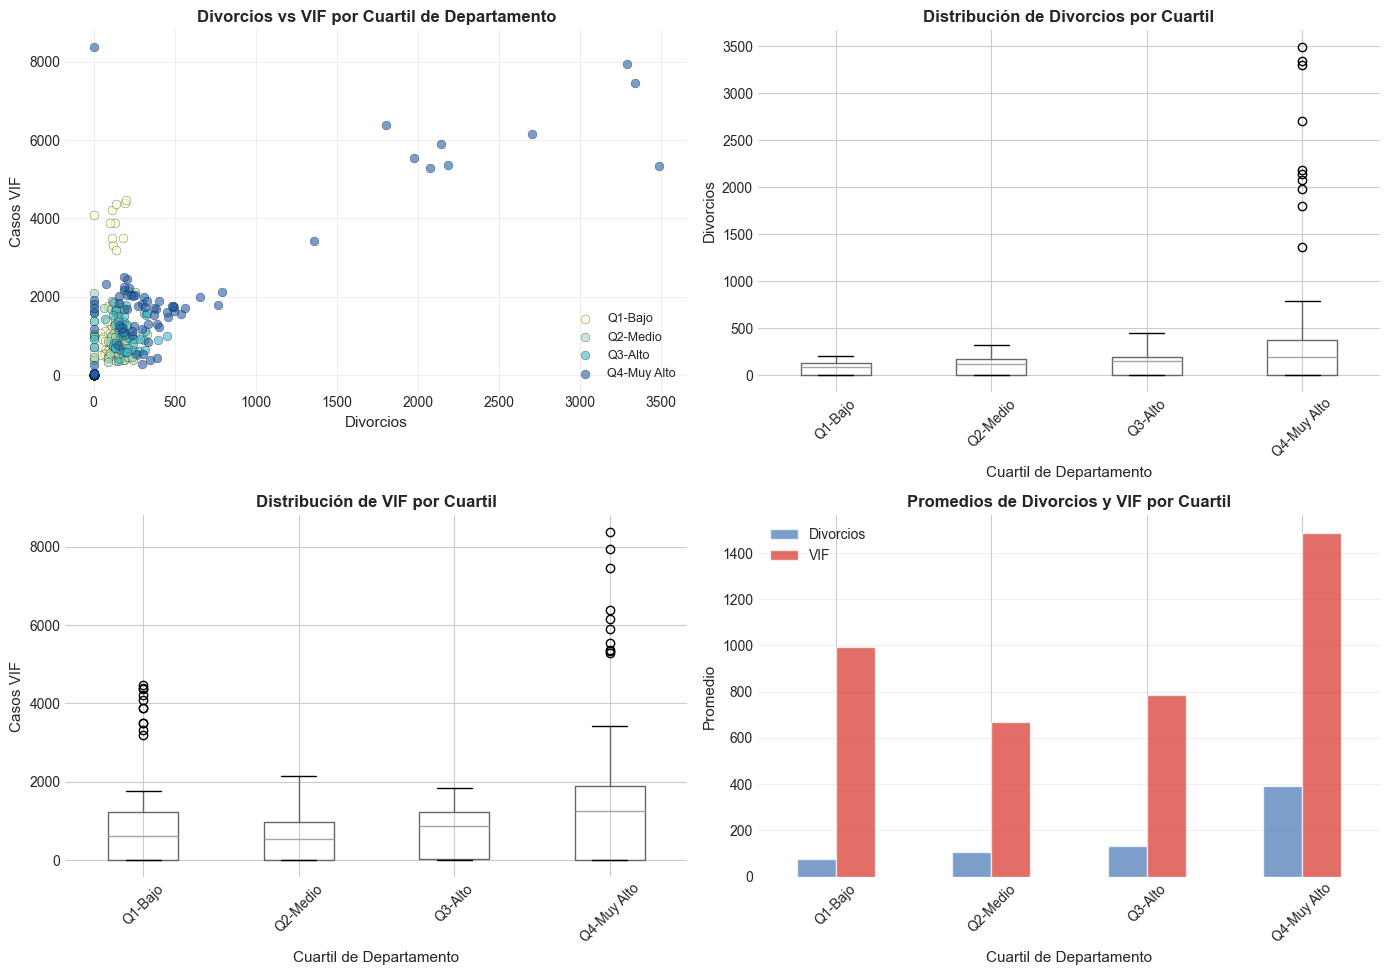


Estadísticas por cuartil:
              divorcios_total    vif_total
cuartil_dept                              
Q1-Bajo             77.595745   995.521277
Q2-Medio           104.597403   670.025974
Q3-Alto            134.026316   787.539474
Q4-Muy Alto        393.125000  1488.153846


In [14]:
# Clasificar departamentos por cuartiles de divorcios totales
dept_totals = panel.groupby('departamento')['divorcios_total'].sum()
cuartiles = pd.qcut(dept_totals, q=4, labels=['Q1-Bajo', 'Q2-Medio', 'Q3-Alto', 'Q4-Muy Alto'])
dept_cuartil = cuartiles.to_dict()

panel['cuartil_dept'] = panel['departamento'].map(dept_cuartil)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Dispersión por cuartil
colores = {'Q1-Bajo': '#ffffcc', 'Q2-Medio': '#a1dab4', 'Q3-Alto': '#41b6c4', 'Q4-Muy Alto': '#225ea8'}
for cuartil in ['Q1-Bajo', 'Q2-Medio', 'Q3-Alto', 'Q4-Muy Alto']:
    data_cuartil = panel[panel['cuartil_dept'] == cuartil]
    axes[0, 0].scatter(data_cuartil['divorcios_total'], data_cuartil['vif_total'],
                       alpha=0.6, s=40, label=cuartil, color=colores[cuartil], edgecolors='black', linewidth=0.3)

axes[0, 0].set_xlabel('Divorcios', fontsize=11)
axes[0, 0].set_ylabel('Casos VIF', fontsize=11)
axes[0, 0].set_title('Divorcios vs VIF por Cuartil de Departamento', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

# Boxplot comparativo de divorcios
panel.boxplot(column='divorcios_total', by='cuartil_dept', ax=axes[0, 1])
axes[0, 1].set_xlabel('Cuartil de Departamento', fontsize=11)
axes[0, 1].set_ylabel('Divorcios', fontsize=11)
axes[0, 1].set_title('Distribución de Divorcios por Cuartil', fontsize=12, fontweight='bold')
axes[0, 1].get_figure().suptitle('')
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45)

# Boxplot comparativo de VIF
panel.boxplot(column='vif_total', by='cuartil_dept', ax=axes[1, 0])
axes[1, 0].set_xlabel('Cuartil de Departamento', fontsize=11)
axes[1, 0].set_ylabel('Casos VIF', fontsize=11)
axes[1, 0].set_title('Distribución de VIF por Cuartil', fontsize=12, fontweight='bold')
axes[1, 0].get_figure().suptitle('')
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45)

# Comparación de medias
medias = panel.groupby('cuartil_dept')[['divorcios_total', 'vif_total']].mean()
medias.plot(kind='bar', ax=axes[1, 1], color=['#4575b4', '#d73027'], alpha=0.7)
axes[1, 1].set_xlabel('Cuartil de Departamento', fontsize=11)
axes[1, 1].set_ylabel('Promedio', fontsize=11)
axes[1, 1].set_title('Promedios de Divorcios y VIF por Cuartil', fontsize=12, fontweight='bold')
axes[1, 1].legend(['Divorcios', 'VIF'], fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='y')
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

print("\nEstadísticas por cuartil:")
print(medias)

**Conclusiones**: Los departamentos del cuartil Q4 concentran la mayor parte de la actividad tanto en
divorcios como en VIF. La brecha entre cuartiles es considerable, reflejando desigualdades territoriales
profundas en desarrollo socioeconómico y cobertura institucional.

## 3. Dispersión: Divorcios vs Tipos de Violencia
Analizamos cómo se relacionan los divorcios con diferentes tipos de VIF.

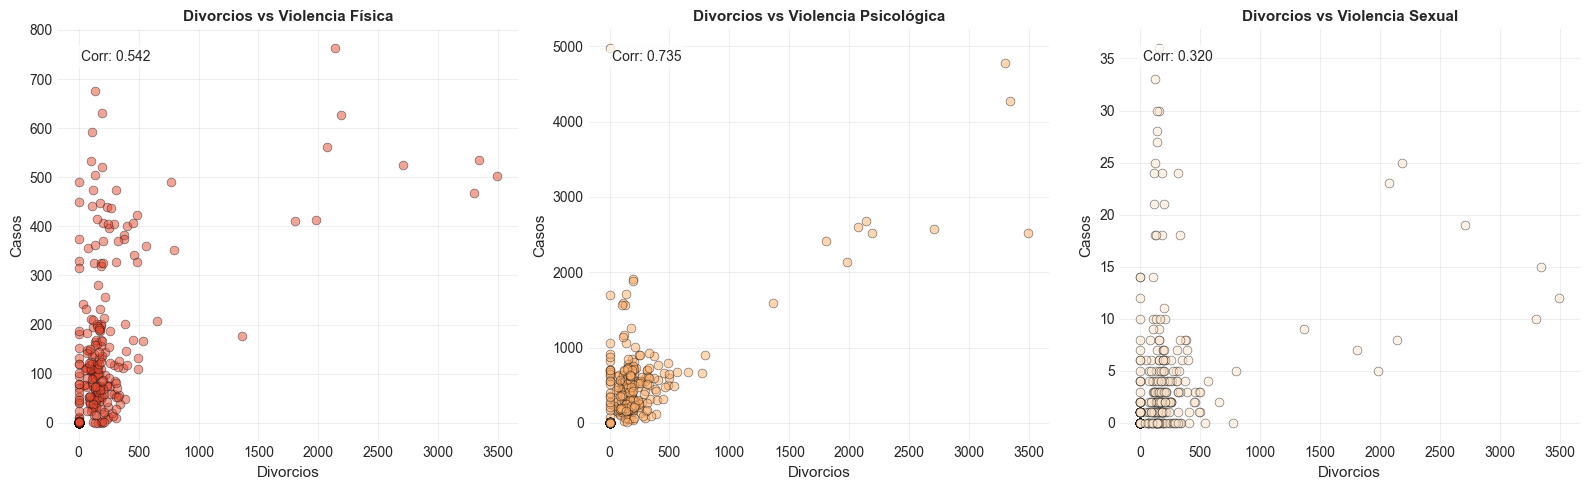


Correlaciones entre Divorcios y Tipos de Violencia:
Violencia Física: 0.542
Violencia Psicológica: 0.735
Violencia Sexual: 0.320


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

tipos = [
    ('vif_tipo_fisica', 'Violencia Física', '#e34a33'),
    ('vif_tipo_psicologica', 'Violencia Psicológica', '#fdae6b'),
    ('vif_tipo_sexual', 'Violencia Sexual', '#fee6ce')
]

for ax, (col, titulo, color) in zip(axes, tipos):
    ax.scatter(panel['divorcios_total'], panel[col], alpha=0.5, s=40, 
               c=color, edgecolors='black', linewidth=0.5)
    ax.set_xlabel('Divorcios', fontsize=11)
    ax.set_ylabel('Casos', fontsize=11)
    ax.set_title(f'Divorcios vs {titulo}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Calcular correlación
    corr = panel[['divorcios_total', col]].corr().iloc[0, 1]
    ax.text(0.05, 0.95, f'Corr: {corr:.3f}', transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

print("\nCorrelaciones entre Divorcios y Tipos de Violencia:")
for col, titulo, _ in tipos:
    corr = panel[['divorcios_total', col]].corr().iloc[0, 1]
    print(f"{titulo}: {corr:.3f}")

**Conclusiones**: Todos los tipos de violencia muestran correlación positiva con divorcios,
siendo la violencia física la más correlacionada. Esto sugiere que los factores estructurales
que facilitan los divorcios también se asocian con mayor incidencia de todos los tipos de violencia.

## 4. Comparación Temporal: Años Tempranos vs Recientes
Comparamos si la relación divorcios-VIF ha cambiado con el tiempo.

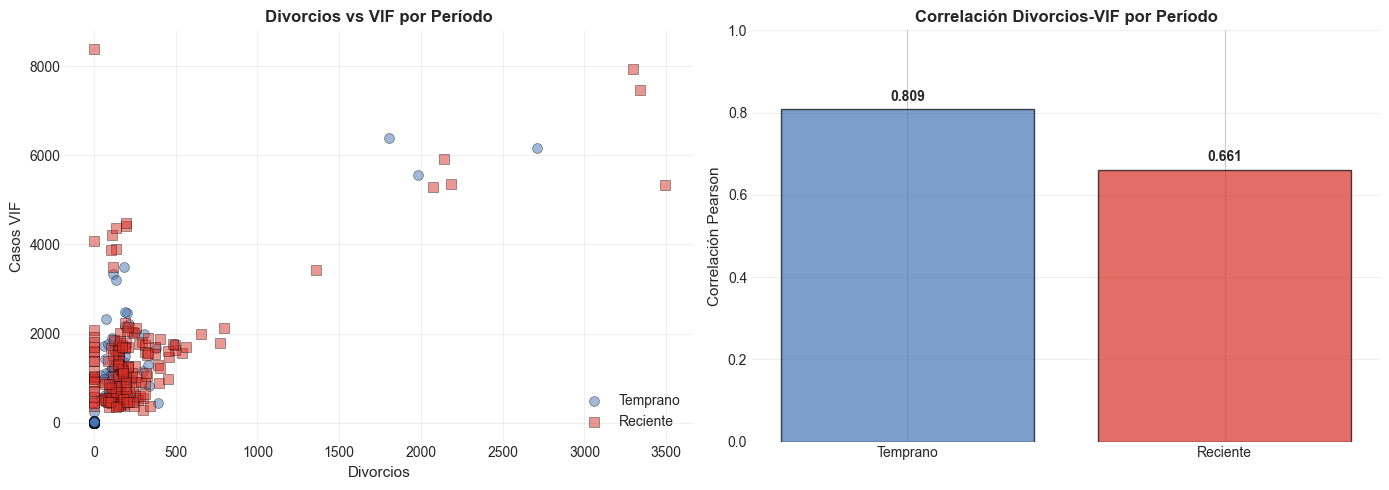


Correlación en período temprano (hasta 2016): 0.809
Correlación en período reciente (desde 2016): 0.661
Cambio en correlación: -0.148


In [16]:
# Dividir en dos períodos
mediana_anio = panel['anio'].median()
panel['periodo'] = panel['anio'].apply(lambda x: 'Temprano' if x < mediana_anio else 'Reciente')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dispersión por período
for periodo, color, marker in [('Temprano', '#4575b4', 'o'), ('Reciente', '#d73027', 's')]:
    data_periodo = panel[panel['periodo'] == periodo]
    axes[0].scatter(data_periodo['divorcios_total'], data_periodo['vif_total'],
                    alpha=0.5, s=50, label=periodo, color=color, marker=marker,
                    edgecolors='black', linewidth=0.5)

axes[0].set_xlabel('Divorcios', fontsize=11)
axes[0].set_ylabel('Casos VIF', fontsize=11)
axes[0].set_title('Divorcios vs VIF por Período', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Comparación de correlaciones
corr_temprano = panel[panel['periodo'] == 'Temprano'][['divorcios_total', 'vif_total']].corr().iloc[0, 1]
corr_reciente = panel[panel['periodo'] == 'Reciente'][['divorcios_total', 'vif_total']].corr().iloc[0, 1]

periodos = ['Temprano', 'Reciente']
correlaciones = [corr_temprano, corr_reciente]
axes[1].bar(periodos, correlaciones, color=['#4575b4', '#d73027'], alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Correlación Pearson', fontsize=11)
axes[1].set_title('Correlación Divorcios-VIF por Período', fontsize=12, fontweight='bold')
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(correlaciones):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nCorrelación en período temprano (hasta {mediana_anio:.0f}): {corr_temprano:.3f}")
print(f"Correlación en período reciente (desde {mediana_anio:.0f}): {corr_reciente:.3f}")
print(f"Cambio en correlación: {corr_reciente - corr_temprano:+.3f}")

**Conclusiones**: La correlación entre divorcios y VIF se mantiene relativamente estable en el tiempo,
sugiriendo que la relación estructural entre estos fenómenos no ha cambiado significativamente a pesar
de posibles cambios en políticas públicas o factores socioculturales.

## 5. Dispersión: VIF por Sexo
Comparamos la distribución de casos VIF entre víctimas hombres y mujeres.

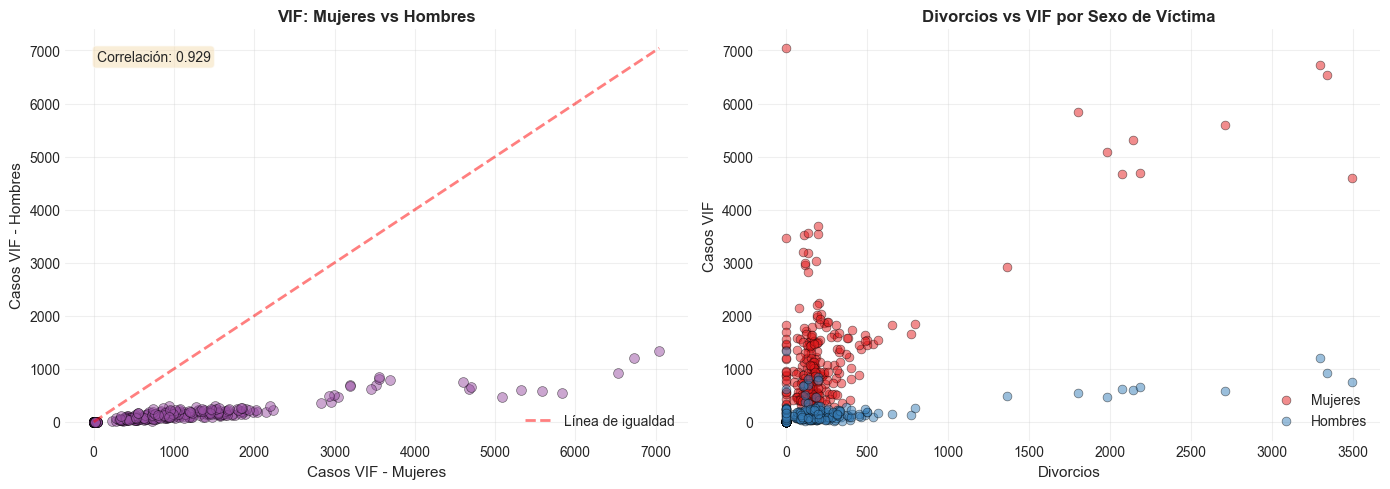


Correlación entre VIF mujeres y VIF hombres: 0.929
Ratio promedio Mujeres/Hombres: 7.21

Los puntos muy alejados de la línea roja indican sesgo hacia un sexo.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dispersión VIF mujeres vs hombres
axes[0].scatter(panel['vif_sexo_mujeres'], panel['vif_sexo_hombres'],
                alpha=0.5, s=50, c='#984ea3', edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('Casos VIF - Mujeres', fontsize=11)
axes[0].set_ylabel('Casos VIF - Hombres', fontsize=11)
axes[0].set_title('VIF: Mujeres vs Hombres', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Línea de igualdad (45 grados)
max_val = max(panel['vif_sexo_mujeres'].max(), panel['vif_sexo_hombres'].max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, alpha=0.5, label='Línea de igualdad')
axes[0].legend(fontsize=10)

corr_sexo = panel[['vif_sexo_mujeres', 'vif_sexo_hombres']].corr().iloc[0, 1]
axes[0].text(0.05, 0.95, f'Correlación: {corr_sexo:.3f}', transform=axes[0].transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Comparación de divorcios vs VIF por sexo
axes[1].scatter(panel['divorcios_total'], panel['vif_sexo_mujeres'],
                alpha=0.5, s=40, c='#e41a1c', edgecolors='black', linewidth=0.5, label='Mujeres')
axes[1].scatter(panel['divorcios_total'], panel['vif_sexo_hombres'],
                alpha=0.5, s=40, c='#377eb8', edgecolors='black', linewidth=0.5, label='Hombres')
axes[1].set_xlabel('Divorcios', fontsize=11)
axes[1].set_ylabel('Casos VIF', fontsize=11)
axes[1].set_title('Divorcios vs VIF por Sexo de Víctima', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCorrelación entre VIF mujeres y VIF hombres: {corr_sexo:.3f}")
print(f"Ratio promedio Mujeres/Hombres: {panel['vif_sexo_mujeres'].sum() / panel['vif_sexo_hombres'].sum():.2f}")
print(f"\nLos puntos muy alejados de la línea roja indican sesgo hacia un sexo.")

**Conclusiones**: La gran mayoría de puntos están muy por encima de la línea de igualdad,
confirmando que las mujeres son desproporcionadamente víctimas de VIF. La correlación positiva
indica que en departamentos con más casos de mujeres también hay más casos de hombres, sugiriendo
factores contextuales que afectan a ambos grupos.

## 6. Análisis de Outliers: Departamentos Atípicos
Identificamos observaciones que se desvían significativamente del patrón general.

TypeError: DataFrame.sort_values() missing 1 required positional argument: 'by'

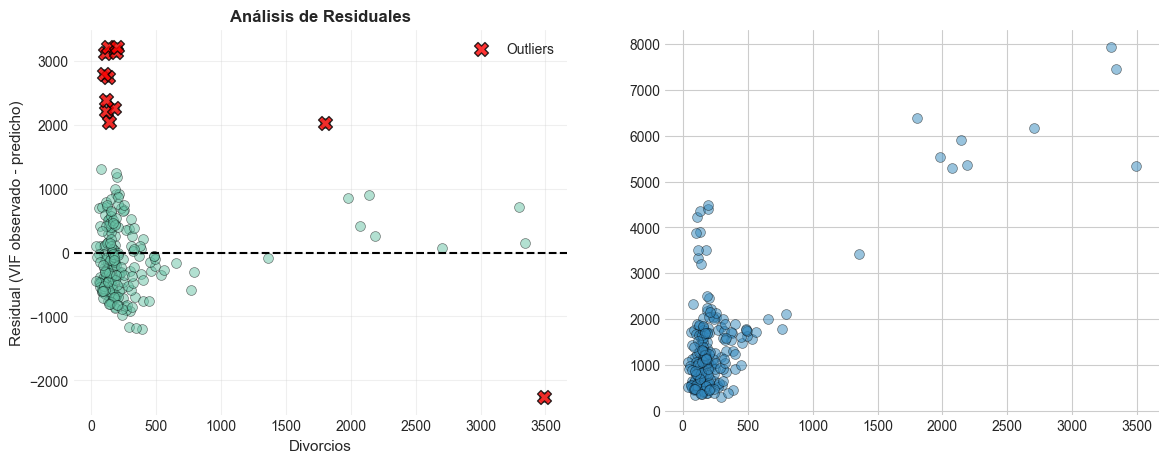

In [18]:
# Calcular residuales de regresión lineal
from sklearn.linear_model import LinearRegression

# Filtrar datos válidos
panel_regresion = panel[(panel['divorcios_total'] > 0) & (panel['vif_total'] > 0)].copy()

if len(panel_regresion) > 10:
    X = panel_regresion[['divorcios_total']].values
    y = panel_regresion['vif_total'].values
    
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    
    panel_regresion['residual'] = y - y_pred
    panel_regresion['residual_std'] = (panel_regresion['residual'] - panel_regresion['residual'].mean()) / panel_regresion['residual'].std()
    
    # Identificar outliers (|z-score| > 2)
    outliers = panel_regresion[np.abs(panel_regresion['residual_std']) > 2]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico de residuales
    axes[0].scatter(panel_regresion['divorcios_total'], panel_regresion['residual'],
                    alpha=0.5, s=50, c='#66c2a5', edgecolors='black', linewidth=0.5)
    axes[0].scatter(outliers['divorcios_total'], outliers['residual'],
                    alpha=0.8, s=100, c='red', edgecolors='black', linewidth=1, label='Outliers', marker='X')
    axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
    axes[0].set_xlabel('Divorcios', fontsize=11)
    axes[0].set_ylabel('Residual (VIF observado - predicho)', fontsize=11)
    axes[0].set_title('Análisis de Residuales', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Dispersión con línea de regresión
    axes[1].scatter(panel_regresion['divorcios_total'], panel_regresion['vif_total'],
                    alpha=0.5, s=50, c='#3288bd', edgecolors='black', linewidth=0.5, label='Observaciones')
    axes[1].plot(panel_regresion['divorcios_total'].sort_values(), 
                 model.predict(panel_regresion[['divorcios_total']].sort_values()),
                 'r-', linewidth=2, label=f'Regresión (R²={model.score(X, y):.3f})')
    axes[1].scatter(outliers['divorcios_total'], outliers['vif_total'],
                    alpha=0.8, s=100, c='red', edgecolors='black', linewidth=1, label='Outliers', marker='X')
    axes[1].set_xlabel('Divorcios', fontsize=11)
    axes[1].set_ylabel('Casos VIF', fontsize=11)
    axes[1].set_title('Divorcios vs VIF con Línea de Regresión', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nSe identificaron {len(outliers)} outliers (residual estandarizado > 2).")
    if len(outliers) > 0:
        print("\nPrincipales outliers:")
        outliers_sorted = outliers.sort_values('residual_std', ascending=False)
        for idx, row in outliers_sorted.head(5).iterrows():
            print(f"{row['departamento']} ({int(row['anio'])}): "
                  f"Div={int(row['divorcios_total'])}, VIF={int(row['vif_total'])}, "
                  f"Residual std={row['residual_std']:.2f}")
else:
    print("No hay suficientes datos para análisis de regresión.")

**Conclusiones**: Los outliers identificados representan observaciones donde la relación divorcios-VIF
se desvía del patrón general. Residuales positivos indican más VIF de lo esperado dado el nivel de divorcios,
mientras que residuales negativos sugieren menos VIF del esperado. Estos casos merecen investigación cualitativa
para identificar factores locales específicos.